In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive (4).zip to archive (4).zip


In [ ]:
import os

os.listdir()

['.config', 'archive (4).zip', 'sample_data']

In [ ]:
import zipfile
import os

zip_path = "archive (4).zip"
extract_path = "/content/fake_news_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
for root, dirs, files in os.walk("/content/fake_news_data"):
    print(root)
    print(files[:10])

/content/fake_news_data
['Fake.csv', 'True.csv']


In [ ]:
import pandas as pd

fake_df = pd.read_csv("/content/fake_news_data/Fake.csv")
true_df = pd.read_csv("/content/fake_news_data/True.csv")

print("Fake News Dataset:", fake_df.shape)
print("True News Dataset:", true_df.shape)

Fake News Dataset: (23481, 4)
True News Dataset: (21417, 4)




The dataset contains two separate groups of news articles: one for fake news and one for real news. The dataset shape shows the number of articles and columns available in each file. The columns provide information such as the article title, full text, subject, and date, which can be used during the analysis and model-building process.

In [ ]:
print("FAKE NEWS")
display(fake_df.head())

print("REAL NEWS")
display(true_df.head())

FAKE NEWS


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


REAL NEWS


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
print("Fake Dataset Info:")
fake_df.info()

print("\nTrue Dataset Info:")
true_df.info()

Fake Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB

True Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB




The dataset information shows the data types and whether any columns contain missing values. This step is important because missing text or titles can affect the machine learning model. If the output shows complete non-null values for the main text columns, the dataset is suitable for further preprocessing.

In [ ]:
fake_df["label"] = 0
true_df["label"] = 1

df = pd.concat([fake_df, true_df], ignore_index=True)

print("Total Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df["label"].value_counts())

Total Dataset Shape: (44898, 5)

Class Distribution:
label
0    23481
1    21417
Name: count, dtype: int64




After assigning labels and combining both files, the dataset contains both fake and real news articles in one dataframe. Label `0` represents fake news and label `1` represents real news. The class distribution helps determine whether the dataset is balanced. A reasonably balanced dataset is useful because the model can learn both classes without being heavily biased toward one category.

In [ ]:
print(df.isnull().sum())

title      0
text       0
subject    0
date       0
label      0
dtype: int64




This output checks for missing values in each column. If all values are zero, no missing data needs to be handled. If missing values are present in important columns such as `title` or `text`, they should be removed or handled before training the model.

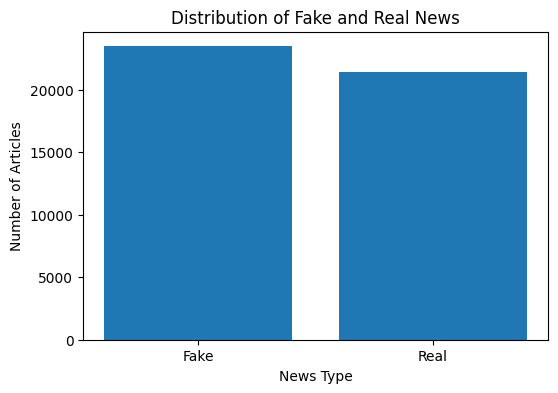

In [ ]:
import matplotlib.pyplot as plt

class_counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Fake", "Real"], class_counts.values)

plt.title("Distribution of Fake and Real News")
plt.xlabel("News Type")
plt.ylabel("Number of Articles")

plt.show()



The bar chart shows the number of fake and real news articles in the combined dataset. Comparing the two bars helps identify whether one class has significantly more samples than the other. A relatively balanced distribution is preferred because it reduces the risk of the model favouring the majority class.

In [ ]:
df["text_length"] = df["text"].astype(str).apply(len)

print(df["text_length"].describe())

count    44898.000000
mean      2469.109693
std       2171.617091
min          1.000000
25%       1234.000000
50%       2186.000000
75%       3105.000000
max      51794.000000
Name: text_length, dtype: float64




The article length statistics describe the variation in the amount of text across the dataset. The minimum, maximum, mean, and percentile values show whether articles have similar or very different lengths. This is useful because article length can affect the number of words and features generated by the TF-IDF vectorizer.

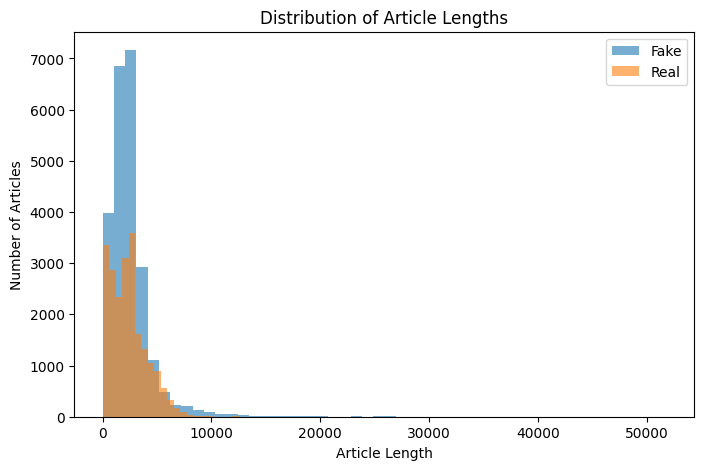

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    df[df["label"] == 0]["text_length"],
    bins=50,
    alpha=0.6,
    label="Fake"
)

plt.hist(
    df[df["label"] == 1]["text_length"],
    bins=50,
    alpha=0.6,
    label="Real"
)

plt.xlabel("Article Length")
plt.ylabel("Number of Articles")
plt.title("Distribution of Article Lengths")
plt.legend()

plt.show()



The histogram compares the text lengths of fake and real news articles. If the distributions overlap heavily, article length alone is unlikely to be enough for classification. This supports the use of TF-IDF and machine learning models, which analyse the words and phrases within the articles rather than relying only on their length.

In [ ]:
df["content"] = (
    df["title"].fillna("") + " " + df["text"].fillna("")
)

df = df[["content", "label"]]

df.head()

,content,label
0,Donald Trump Sends Out Embarrassing New Year’...,0
1,Drunk Bragging Trump Staffer Started Russian ...,0
2,Sheriff David Clarke Becomes An Internet Joke...,0
3,Trump Is So Obsessed He Even Has Obama’s Name...,0
4,Pope Francis Just Called Out Donald Trump Dur...,0




The title and article text are combined into a single `content` feature. This allows the model to use information from both the headline and the full article. The final dataframe now contains only the input text and the target label, which simplifies the machine learning pipeline.

In [ ]:
from sklearn.utils import shuffle

df = shuffle(df, random_state=42).reset_index(drop=True)

df.head()

,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,0
4,Donald Trump heads for Scotland to reopen a go...,1




The dataset is shuffled so that fake and real news articles are mixed randomly. This is necessary because the two datasets were originally combined in separate groups. Shuffling reduces the risk of the training and testing data being ordered by class.

In [ ]:
from sklearn.model_selection import train_test_split

X = df["content"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 35918
Testing samples: 8980




The dataset is divided into training and testing sets. The training set is used to teach the model, while the testing set is kept separate to measure performance on unseen data. Stratification ensures that both sets contain a similar proportion of fake and real news articles.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_df=0.7,
    max_features=50000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Training TF-IDF Shape: (35918, 50000)
Testing TF-IDF Shape: (8980, 50000)




TF-IDF converts the text into numerical features that machine learning models can process. Important words and word pairs receive higher weights based on how informative they are across the dataset. The output shape shows the number of articles and the number of features created for training and testing.

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

lr_predictions = lr_model.predict(X_test_tfidf)

print("Logistic Regression training complete!")

Logistic Regression training complete!




Logistic Regression is trained using the TF-IDF features. The model learns patterns in the text that are associated with fake and real news. After training, it can predict the class of previously unseen articles.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Accuracy:", lr_accuracy)
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    lr_predictions,
    target_names=["Fake", "Real"]
))

Accuracy: 0.9881959910913141

Classification Report:

              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4696
        Real       0.98      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980





The accuracy shows the overall percentage of correct predictions. Precision measures how reliable the model's predictions are for each class, recall measures how many actual examples of each class were identified correctly, and the F1-score combines precision and recall. High and similar scores for both classes indicate that the model performs consistently rather than working well for only one class.

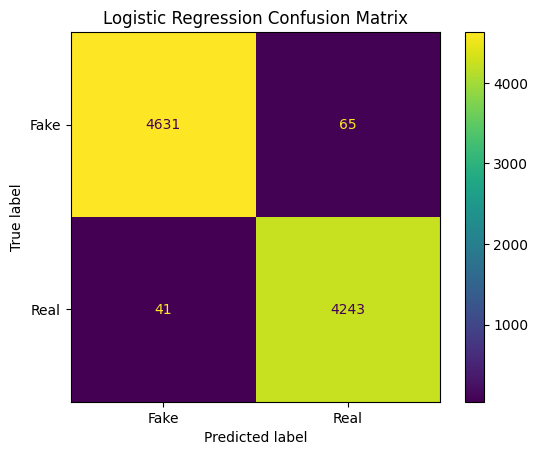

In [ ]:
cm = confusion_matrix(y_test, lr_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()



The confusion matrix provides a detailed view of correct and incorrect predictions. Values on the main diagonal represent correct classifications, while off-diagonal values represent mistakes. A strong model should have most predictions concentrated on the diagonal.

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_predictions = nb_model.predict(X_test_tfidf)

nb_accuracy = accuracy_score(y_test, nb_predictions)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.9564587973273943




Multinomial Naive Bayes is trained as a second model for comparison. It is commonly used for text classification because it works efficiently with word-frequency and TF-IDF features. Its accuracy can be compared with Logistic Regression to select the better-performing model.

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes"
    ],
    "Accuracy": [
        lr_accuracy,
        nb_accuracy
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.988196
1,Multinomial Naive Bayes,0.956459




This table directly compares the accuracy of Logistic Regression and Multinomial Naive Bayes. The model with the higher test accuracy is the better choice based on this evaluation. However, the final decision should also consider precision, recall, and F1-score rather than accuracy alone.

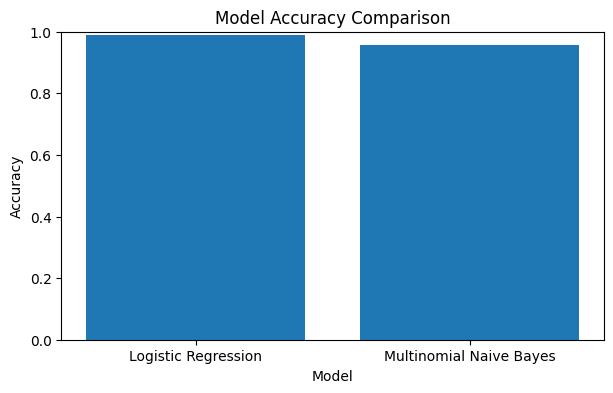

In [ ]:
plt.figure(figsize=(7, 4))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)
plt.show()



The chart provides a visual comparison of the two models. A higher bar represents better test accuracy. This makes it easier to identify which model performed better on the same dataset and test split.

In [ ]:
def predict_news(text):
    text_vector = tfidf.transform([text])
    prediction = lr_model.predict(text_vector)[0]
    probability = lr_model.predict_proba(text_vector)[0]

    if prediction == 0:
        result = "FAKE NEWS"
    else:
        result = "REAL NEWS"

    confidence = max(probability) * 100

    print("Prediction:", result)
    print(f"Model Confidence: {confidence:.2f}%")

In [ ]:
sample_news = """
Scientists announce a major breakthrough in renewable energy technology,
claiming that the new system could significantly improve energy storage.
"""

predict_news(sample_news)

Prediction: REAL NEWS
Model Confidence: 51.98%




The custom prediction demonstrates how the trained model can classify new text that was not directly selected from the test set. The result should be interpreted carefully: the model predicts patterns learned from this specific dataset and does not independently verify whether a real-world news claim is factually true or false.

In [ ]:
import joblib

joblib.dump(lr_model, "fake_news_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and TF-IDF vectorizer saved successfully!")

Model and TF-IDF vectorizer saved successfully!




The trained Logistic Regression model and TF-IDF vectorizer are saved for later use. Both files are required because the vectorizer must transform new text in the same way as the training data before the saved model can make predictions.

## Final Conclusion

This project uses Natural Language Processing and machine learning to classify news articles as fake or real based on patterns learned from the provided dataset. The workflow includes data preparation, exploratory analysis, TF-IDF feature extraction, model training, evaluation, and prediction on new text.

The model comparison identifies the stronger algorithm based on test performance. However, the system should not be presented as a fact-checking tool. It classifies articles according to patterns in its training data and may not generalize to all future or real-world news sources.